# 05 — โมเดลแรก: Logistic Regression

ตาราง features จากบท 04 พร้อมแล้ว — วันนี้ได้เทรนโมเดลจริงๆ สักที 🎉
แต่บทนี้ไม่ได้สอนแค่ "กดปุ่ม fit" นะครับ หัวใจจริงๆ คือ **วัดผลให้เป็น**
เพราะปัญหา churn ของเรามีตัวจริงแค่ ~9% — สนามที่ตัวเลขสวยๆ หลอกคนมาเยอะที่สุด

**สิ่งที่จะได้จากบทนี้ (~90 นาที):**
1. ประกอบท่อเตรียมข้อมูลแบบมืออาชีพ: `ColumnTransformer` + `Pipeline`
   (เติม NaN, สเกลตัวเลข, one-hot หมวดหมู่ — และกัน leakage ให้อัตโนมัติ)
2. เห็นกับตาว่าทำไม **accuracy โกหก** เมื่อ churn ~9% แล้วหันไปใช้
   precision / recall / PR curve / Average Precision แทน
3. แปลคะแนนโมเดลเป็นภาษาธุรกิจ: **precision@30 = "mentor โทร 30 สาย เจอตัวจริงกี่คน"**
4. จับโมเดลขึ้นสังเวียนชกกับ baseline: เดามั่ว vs ระบบ tier ที่ mentor ใช้อยู่ — ใครชนะ?

In [1]:
import os; os.environ.setdefault("ML_CHURN_DATA", "sample")  # repo สาธารณะรันบนข้อมูลสังเคราะห์ (โปรเจกต์ภายในตั้ง =real)
import sys; sys.path.insert(0, "..")
import pandas as pd
from src import checks, churn_utils, contracts
from src.config import DATA_DIR, IS_SAMPLE
plt = churn_utils.plot_style()
print("โหมดข้อมูล:", "SAMPLE (ข้อมูลจำลอง)" if IS_SAMPLE else f"REAL ({DATA_DIR})")

โหมดข้อมูล: SAMPLE (ข้อมูลจำลอง)


## เตรียมของ: rebuild features สด + แบ่ง train/test ตามเวลา

เราสร้าง features ใหม่ตรงนี้เลยด้วยฟังก์ชัน canonical จาก `src/churn_utils`
(ตัวเดียวกับเฉลยบท 04 — ใช้เวลาไม่กี่วินาที และถึงยังไม่ได้ทำบท 04 สมุดเล่มนี้ก็รันได้)

สองการตัดสินใจสำคัญก่อนแตะโมเดล:

1. **ทิ้งแถวที่ label เป็น NaN** — แถว censored (เช่น ก.ย. = จบซีซันปกติ) ไม่มีเฉลย
   ใช้สอนหรือสอบโมเดลไม่ได้ (แต่ตอนใช้งานจริงบท 08 แถวพวกนี้แหละคือลูกค้าของเรา)
2. **แบ่งตามเวลา ไม่สุ่ม**: ปี 2568 = ข้อสอน · ปี 2569 = ข้อสอบ — เพราะตอนใช้จริง
   เราใช้อดีตทำนายอนาคต*เสมอ* ถ้าสุ่มแบ่ง เดือนอนาคตจะปนเข้าไปในข้อสอน
   = โมเดลแอบเห็นเฉลย (กฎเหล็กบท 04 ตามมาหลอกหลอนทุกบทจริงๆ ครับ 😄)

In [2]:
import numpy as np

labels   = pd.read_csv(DATA_DIR / "labels_monthly.csv", dtype={"month": str}, parse_dates=["churn_date"])
att_long = pd.read_csv(DATA_DIR / "attendance_long.csv", parse_dates=["ep_final_date", "week_start"])
attempts = pd.read_csv(DATA_DIR / "exam_attempts.csv", parse_dates=["submitted_at"])
weekly   = pd.read_csv(DATA_DIR / "weekly_metrics.csv", parse_dates=["week_start", "week_end"])
students = pd.read_csv(DATA_DIR / "students.csv", parse_dates=["signup_date"])

# features ชุด canonical (สูตรเดียวกับตอนใช้งานจริง — กัน train/serve skew)
features = churn_utils.build_features_monthly(labels, att_long, attempts, weekly, students)
labeled = features.dropna(subset=["churned_next_month"]).copy()

# --- ตัด 103 คู่ (คน, เดือน) ที่ข้อมูลกำกวมออกจากการเทรน — ตามที่ CEO ตัดสิน 11 ส.ค. 2026 (docs/data-dictionary.md) ---
_excl_path = DATA_DIR.parent / "raw" / "labels" / "exclude_pairs_2569.csv"
_excl = (pd.read_csv(_excl_path, dtype={"month": str}) if _excl_path.exists()
         else pd.DataFrame(columns=["student_key", "month"]))  # sample: ไม่มีคู่กำกวมให้ตัด
_before = len(labeled)
labeled = (labeled.merge(_excl[["student_key", "month"]], on=["student_key", "month"], how="left", indicator=True)
                  .query('_merge == "left_only"').drop(columns="_merge"))
print(f"exclude_pairs: ตัดออก {_before - len(labeled)} แถว → เหลือเทรน/ทดสอบ {len(labeled)} แถว")
# ตัดนักเรียนสายเทป 29 คนออกจาก scope โมเดล — CEO ยืนยันรายชื่อ 29 ส.ค. 2026 (แยกไปเลนดูแลต่างหาก)
_replay_path = DATA_DIR.parent / "raw" / "labels" / "replay_students_2569.csv"
_replay = set(pd.read_csv(_replay_path)["student_key"]) if _replay_path.exists() else set()  # sample: ไม่มีสายเทป
_b = len(labeled)
labeled = labeled[~labeled["student_key"].isin(_replay)].reset_index(drop=True)
print(f"replay: ตัดออก {_b - len(labeled)} แถว (สายเทป) → เหลือ {len(labeled)} แถว")

train_df = labeled[labeled["year"] == 2568].copy()   # ข้อสอน: ซีซันที่จบแล้ว
test_df  = labeled[labeled["year"] == 2569].copy()   # ข้อสอบ: ซีซันปัจจุบัน

NUM_COLS = list(churn_utils.NUMERIC_FEATURES)        # 13 คอลัมน์ตัวเลข
CAT_COLS = list(churn_utils.CATEGORICAL_FEATURES)    # grade, live_or_replay, old_new

X_train, y_train = train_df[NUM_COLS + CAT_COLS], train_df["churned_next_month"]
X_test,  y_test  = test_df[NUM_COLS + CAT_COLS],  test_df["churned_next_month"]

print(f"features ทั้งหมด    : {features.shape[0]:,} แถว | มี label ใช้ได้ {len(labeled):,} แถว")
print(f"train ปี 2568       : {len(train_df):,} แถว (churn {y_train.mean():.1%})")
print(f"test  ปี 2569       : {len(test_df):,} แถว (churn {y_test.mean():.1%} = ตัวจริง {int(y_test.sum())} เคส)")

exclude_pairs: ตัดออก 0 แถว → เหลือเทรน/ทดสอบ 1333 แถว
replay: ตัดออก 0 แถว (สายเทป) → เหลือ 1333 แถว
features ทั้งหมด    : 1,610 แถว | มี label ใช้ได้ 1,333 แถว
train ปี 2568       : 763 แถว (churn 7.9%)
test  ปี 2569       : 570 แถว (churn 10.0% = ตัวจริง 57 เคส)


## ก่อนแตะโมเดล — ขอเล่าเรื่อง "หมอดูขี้เกียจ" ก่อน

สมมติเราจ้างหมอดูคนหนึ่งมาทำนาย churn เขาขี้เกียจมาก ทายเหมือนกันทุกคนว่า
*"ไม่หายหรอกน้องคนนี้ อยู่ยาวๆ"* — ฟังดูไร้ประโยชน์สุดๆ ใช่ไหมครับ
ลองวัดฝีมือแกด้วย **accuracy** (สัดส่วนที่ทายถูก) ดูสิ...

In [3]:
y_all = labeled["churned_next_month"]
print(f"อัตรา churn จริง (ทุกแถวที่มี label) : {y_all.mean():.1%}")
print(f"accuracy ของหมอดูขี้เกียจ           : {(y_all == 0).mean():.1%}   ← ว้าว เก่งจัง?!")
print(f"เด็กเสี่ยงที่หมอดูหาเจอ              : 0 คน จากตัวจริง {int(y_all.sum())} เคส")

อัตรา churn จริง (ทุกแถวที่มี label) : 8.8%
accuracy ของหมอดูขี้เกียจ           : 91.2%   ← ว้าว เก่งจัง?!
เด็กเสี่ยงที่หมอดูหาเจอ              : 0 คน จากตัวจริง 117 เคส


> ⚠️ **กับดัก! Accuracy trap — ตัวเลขสวยที่ไร้ประโยชน์ที่สุดในปัญหา churn**
> เมื่อตัวจริงมีแค่ ~9% การ "ทายว่าไม่มีใคร churn" ก็ได้ accuracy ~91% ฟรีๆ
> โมเดลที่โชว์ accuracy 91% จึงอาจ**ไม่ได้ช่วยอะไรเราเลยแม้แต่คนเดียว**
> สิ่งที่ธุรกิจต้องการไม่ใช่ "ทายถูกเยอะ" แต่คือ **"ชี้ตัวเด็กเสี่ยงให้เจอ"** —
> ตัววัดของบทนี้ทั้งบทเลยเป็นตระกูล precision / recall / AP ที่โฟกัสตัวจริง
> กติกาทีมเรา: รายงานผลโมเดล churn ห้ามพาดหัวด้วย accuracy เด็ดขาด

## [แนวคิด] 5.1 ColumnTransformer — ครัวเตรียมวัตถุดิบก่อนเสิร์ฟโมเดล

โมเดลกินได้แต่ **ตัวเลขล้วนๆ ไม่มีรู** — แต่ตารางเรามีครบทุกปัญหา:
NaN (เดือนที่ไม่มีคลาส / เด็กไม่เคยทำข้อสอบ), สเกลคนละโลก (`att_month_pct` 0–100
vs `n_subjects` 1–6), และคอลัมน์ตัวหนังสือ (`ม.3`, `สด`, `old`) — เลยต้องมีครัว 2 สถานี:

- **สถานีตัวเลข**: `SimpleImputer(strategy="median")` เติมรู (median เพราะทนค่าโดด
  และ NaN แปลว่า "ไม่รู้" ไม่ใช่ศูนย์!) ต่อด้วย `StandardScaler` ให้ทุก feature เสียงดังเท่ากัน
- **สถานีหมวดหมู่**: `OneHotEncoder(handle_unknown="ignore")` แตกเป็นคอลัมน์ 0/1 —
  ตั้ง `ignore` ไว้กันเคสข้อมูลใหม่มีค่าที่ปี 68 ไม่เคยเห็น (ได้ 0 ทุกช่องแทนที่จะ crash)

`ColumnTransformer` คือผังที่บอกว่า *คอลัมน์ไหนเข้าสถานีไหน* — เขียนครั้งเดียว ใช้ทั้งโปรเจกต์

In [4]:
# ตัวอย่าง (เคสคู่ขนาน): ตารางจิ๋วที่มีครบทุกปัญหา — NaN + สเกลต่าง + ตัวหนังสือ
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

toy = pd.DataFrame({
    "hours_online": [5.0, np.nan, 2.0, 8.0],        # มีรู NaN
    "quiz_score":   [55.0, 80.0, np.nan, 95.0],
    "plan":         ["รายเดือน", "รายเดือน", "คอร์สสั้น", "รายเดือน"],
})
toy_prep = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), ["hours_online", "quiz_score"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["plan"]),
])
out = toy_prep.fit_transform(toy)
print(pd.DataFrame(out, columns=toy_prep.get_feature_names_out()).round(2))

# พลังของ handle_unknown="ignore": ค่า "รายปี" ไม่เคยเห็นตอน fit → ได้ 0 ทุกช่อง ไม่ crash
new = pd.DataFrame({"hours_online": [3.0], "quiz_score": [70.0], "plan": ["รายปี"]})
print("\nแถวใหม่ plan='รายปี':", toy_prep.transform(new).round(2))

   num__hours_online  num__quiz_score  cat__plan_คอร์สสั้น  cat__plan_รายเดือน
0               0.00            -1.57                  0.0                 1.0
1               0.00             0.17                  0.0                 1.0
2              -1.41             0.17                  1.0                 0.0
3               1.41             1.22                  0.0                 1.0

แถวใหม่ plan='รายปี': [[-0.94 -0.52  0.    0.  ]]


### [แบบฝึกหัด 5.1] สร้าง ColumnTransformer ของจริง

ทำแบบเดียวกับตัวอย่าง แต่ใช้คอลัมน์จริงของเรา (`NUM_COLS` 13 ตัว + `CAT_COLS` 3 ตัว
เตรียมไว้ให้แล้วใน cell setup)

**คำสั่ง:**
1. สร้าง `prep` = `ColumnTransformer` ที่มี 2 เส้นทาง:
   - `("num", ..., NUM_COLS)` — `Pipeline` ของ `SimpleImputer(strategy="median")`
     ต่อด้วย `StandardScaler()`
   - `("cat", ..., CAT_COLS)` — `OneHotEncoder(handle_unknown="ignore")`
2. ยังไม่ต้อง fit — ข้อนี้ตรวจโครงสร้างของท่อ (ทุกคลาส import ไว้แล้วใน cell ตัวอย่าง)

**ผลลัพธ์ที่คาด:** check ผ่าน — และพอ fit กับ `X_train` (16 คอลัมน์) มันจะแปลงเป็น
เมทริกซ์ 20 คอลัมน์ (13 ตัวเลข + one-hot 7: grade 3 + live_or_replay 2 + old_new 2)

In [5]:
# TODO: ประกอบ prep สองเส้นทาง — ("num", Pipeline([imputer, scaler]), NUM_COLS)
#       และ ("cat", OneHotEncoder(...), CAT_COLS)
____ = None   # ← ลบบรรทัดนี้ แล้วเขียนโค้ดของคุณแทน

prep = ColumnTransformer([
    ("num",
     Pipeline([("imputer", SimpleImputer(strategy="median")),
               ("scaler", StandardScaler())]),
     NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])


checks.check("ex_05_01", prep)   # ยังไม่ผ่านจนกว่าจะเติมถูก — ปกติ!

ผ่าน ✓  (ex_05_01) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

โครงเหมือนครัวจิ๋วในตัวอย่างเป๊ะ — เปลี่ยนแค่ลิสต์คอลัมน์เป็นสองลิสต์จริง
ที่เตรียมไว้ให้ใน cell setup · เส้นทางตัวเลขต้องห่อสองขั้นไว้ในท่อเดียวกัน
(เติมรูก่อน แล้วค่อยสเกล — ลำดับสำคัญ) ส่วนเส้นทางหมวดหมู่ใช้ตัวแตก one-hot
เดี่ยวๆ ได้เลย และอย่าลืมตั้งค่าให้มันเมินค่าที่ไม่เคยเห็นตอน fit แทนที่จะพัง

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `ColumnTransformer([(ชื่อ, transformer, ลิสต์คอลัมน์), ...])` — สองเส้นทาง num / cat
- เส้นทาง num: `Pipeline([("imputer", ...), ("scaler", ...)])` จาก
  `SimpleImputer(strategy="median")` + `StandardScaler()`
- เส้นทาง cat: `OneHotEncoder(handle_unknown="ignore")`

</details>

In [6]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_05_01.py

In [7]:
# checkpoint: เวอร์ชัน canonical ของ 5.1 (สูตรเดียวกับเฉลย) — ใช้เดินเรื่องต่อได้แม้ข้อบนยังไม่ผ่าน
prep_ok = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
print("แปลง X_train:", X_train.shape, "→", prep_ok.fit_transform(X_train).shape, "(13 num + one-hot 7)")

แปลง X_train: (763, 16) → (763, 20) (13 num + one-hot 7)


## [แนวคิด] 5.2 Pipeline + LogisticRegression — สอนด้วยปี 68 สอบด้วยปี 69

`Pipeline` ต่อครัว (prep) เข้ากับเชฟ (โมเดล) เป็นเครื่องเดียว: เรียก `.fit(X_train, y_train)`
ทีเดียว มันจะ fit *ทุกชิ้น* ด้วยข้อมูล train เท่านั้น แล้วตอน `.predict_proba(X_test)`
ก็แค่ transform ตามสูตรที่เรียนมา — กัน leakage ให้เราแบบอัตโนมัติ

**Logistic Regression** คือโมเดลเส้นตรงใจดี: ถ่วงน้ำหนักแต่ละ feature รวมเป็นคะแนน
แล้วบีบให้อยู่ระหว่าง 0–1 เป็นความน่าจะเป็น — เรียบง่าย เร็ว และ*อธิบายได้*
(บท 07 เราจะเปิดฝาอ่านน้ำหนักพวกนี้เล่าให้ mentor ฟังกันเลย)

ของสำคัญ 2 ชิ้นในข้อนี้:
- `class_weight="balanced"` — ขยายเสียงเด็ก churn (~8% ของ train) ให้ดังเท่าเด็กปกติ
  ไม่งั้นโมเดลจะกลายร่างเป็นหมอดูขี้เกียจซะเอง
- `predict_proba(...)[:, 1]` — เราไม่เอาคำตอบ 0/1 แต่เอา**คะแนนความเสี่ยง** มาเรียงลำดับ
  เพราะคำถามธุรกิจจริงคือ "ใครควรอยู่หัวลิสต์โทรของ mentor" 

In [8]:
# ตัวอย่าง (เคสคู่ขนาน): pipeline จิ๋วบนตาราง toy — fit แล้วขอความน่าจะเป็น
from sklearn.linear_model import LogisticRegression

toy_y = [0, 1, 0, 1]

toy_model = Pipeline([
    ("prep", toy_prep),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000)),
])
toy_model.fit(toy, toy_y)

print("predict_proba คืน 2 คอลัมน์: [P(อยู่ต่อ), P(churn)]")
print(toy_model.predict_proba(toy).round(3))
print("\nคะแนนความเสี่ยง (คอลัมน์ [:, 1]):", toy_model.predict_proba(toy)[:, 1].round(3))

predict_proba คืน 2 คอลัมน์: [P(อยู่ต่อ), P(churn)]
[[0.701 0.299]
 [0.423 0.577]
 [0.736 0.264]
 [0.14  0.86 ]]

คะแนนความเสี่ยง (คอลัมน์ [:, 1]): [0.299 0.577 0.264 0.86 ]


> ⚠️ **กับดัก! "ห้าม fit อะไรก็ตามบนข้อมูลที่มี test ปน" — โมเดลไม่ใช่ผู้ต้องสงสัยรายเดียว**
> `StandardScaler` ก็ leak ได้! ถ้าเผลอ `fit_transform` บนข้อมูลทั้งก้อน (68+69) ก่อนแบ่ง
> ค่า mean/std จะแอบพกข้อมูลปี 69 เข้าไปในข้อสอน — โกงแบบเนียนๆ ที่เจอบ่อยสุดในโลกจริง
> (imputer ก็เช่นกัน: median ที่คำนวณจาก test = โกง)
> ทางกันพลาดคือท่อที่เราเพิ่งสร้าง: **ยัดทุกอย่างไว้ใน Pipeline แล้ว fit ด้วย train เท่านั้น**
> กฎจำง่าย: ข้อมูล test มีสิทธิ์โดนแค่ `.transform` / `.predict` — ห้ามโดน `.fit` เด็ดขาด

### [แบบฝึกหัด 5.2] เทรนโมเดลแรกของ EWT

**คำสั่ง:**
1. สร้าง `model` = `Pipeline` 2 ขั้น: `("prep", prep_ok)` →
   `("clf", LogisticRegression(class_weight="balanced", max_iter=2000))`
2. `fit` ด้วย `X_train, y_train` (ปี 2568 ล้วนๆ!)
3. `proba` = คะแนนความเสี่ยงของ **X_test** (ปี 2569) — เฉพาะคอลัมน์ P(churn)
4. ส่ง `(model, proba)` เข้า check (จัดรูปให้แล้วใน skeleton)

**ผลลัพธ์ที่คาด:** `proba` เป็นอาเรย์ 570 ค่า อยู่ช่วงประมาณ 0.02–0.90
— นี่แหละ "ความเห็น" ของโมเดลต่อเด็กปี 69 ทุกคนทุกเดือน

In [9]:
# TODO: ประกอบ Pipeline → fit ปี 68 → ขอคะแนนเสี่ยงปี 69
____ = None   # ← ลบบรรทัดนี้ แล้วเขียนโค้ดของคุณแทน

model = Pipeline([
    ("prep",prep_ok),
    ("clf",LogisticRegression(class_weight="balanced",max_iter=2000)),
])
model.fit(X_train,y_train)
proba = model.predict_proba(X_test)[:,1]

checks.check("ex_05_02", (model, proba))

ผ่าน ✓  (ex_05_02) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

สามจังหวะ: ประกอบ → สอน → สอบ · ตอนประกอบใช้ครัว canonical จาก checkpoint
ข้อ 5.1 เป็นขั้นแรกได้เลย (หรือครัวของคุณเองถ้าข้อ 5.1 ผ่านแล้ว) ·
ตอนสอนป้อนเฉพาะข้อสอนปี 2568 · ตอนสอบอย่าลืมว่าความน่าจะเป็นที่ได้กลับมา
มีสองคอลัมน์ — ความเสี่ยง churn คือคอลัมน์ที่สอง

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `Pipeline([("prep", ...), ("clf", ...)])`
- `LogisticRegression(class_weight="balanced", max_iter=2000)`
- `.fit(...)` — ป้อนข้อสอนเท่านั้น · `.predict_proba(...)[:, 1]`

</details>

In [10]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_05_02.py

In [11]:
# checkpoint: เวอร์ชัน canonical ของ 5.2 — โมเดล + คะแนนเสี่ยงที่บทที่เหลือจะใช้ต่อ
model_ok = Pipeline([
    ("prep", prep_ok),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000)),
])
model_ok.fit(X_train, y_train)
proba_ok = model_ok.predict_proba(X_test)[:, 1]
print(f"proba_ok: {len(proba_ok)} ค่า | ช่วง {proba_ok.min():.3f}–{proba_ok.max():.3f}")

proba_ok: 570 ค่า | ช่วง 0.023–0.895


In [12]:
# ทำไมต้อง class_weight="balanced"? — ลองถอดออกดูก็รู้เลย
plain = Pipeline([("prep", prep_ok), ("clf", LogisticRegression(max_iter=2000))])
plain.fit(X_train, y_train)
print("ธง 'เสี่ยง' ที่เกณฑ์ 0.5 — ไม่ถ่วงน้ำหนัก :", int(plain.predict(X_test).sum()), "คน   ← หมอดูขี้เกียจกลับชาติมาเกิด!")
print("ธง 'เสี่ยง' ที่เกณฑ์ 0.5 — balanced      :", int(model_ok.predict(X_test).sum()), "คน   ← ตื่นแล้ว แต่ 121 สายก็โทรไม่ไหว...")
print("→ ทางออกไม่ใช่เกณฑ์ 0.5 แต่คือ 'เรียงคะแนนแล้วโทรตามงบ' — หน่วยถัดไปเลยครับ")

ธง 'เสี่ยง' ที่เกณฑ์ 0.5 — ไม่ถ่วงน้ำหนัก : 0 คน   ← หมอดูขี้เกียจกลับชาติมาเกิด!
ธง 'เสี่ยง' ที่เกณฑ์ 0.5 — balanced      : 121 คน   ← ตื่นแล้ว แต่ 121 สายก็โทรไม่ไหว...
→ ทางออกไม่ใช่เกณฑ์ 0.5 แต่คือ 'เรียงคะแนนแล้วโทรตามงบ' — หน่วยถัดไปเลยครับ


## [แนวคิด] 5.3 Precision / Recall / PR curve — ภาษาของคนตามหาตัวจริง

ลิสต์ที่โมเดลชี้ว่า "เสี่ยง" วัดคุณภาพได้ 2 มุมเสมอ:

- **Precision** — ในลิสต์ที่ชี้มา เป็นตัวจริงกี่ส่วน → *"mentor โทรฟรีน้อยแค่ไหน"*
- **Recall** — ตัวจริงทั้งหมด เก็บเข้าลิสต์ได้กี่ส่วน → *"เด็กเสี่ยงหลุดมือเราไปกี่คน"*

สองตัวนี้เป็นไม้กระดก: ขยับเกณฑ์ (threshold) ให้เข้มขึ้น → precision ขึ้น แต่ recall ร่วง
เกณฑ์เดียวเล่าเรื่องไม่ครบ **PR curve** เลยลากให้ดู*ทุกเกณฑ์*ในภาพเดียว
และ **Average Precision (AP)** สรุปทั้ง curve เป็นเลขตัวเดียว (≈ พื้นที่ใต้ curve):
1.0 = เรียงเด็กเสี่ยงไว้หัวแถวได้เพอร์เฟกต์ · เดามั่ว ≈ base rate (ของเราคือ 0.10)

เกณฑ์ 0.65: ชี้ 3 คน → ตัวจริง 2 | precision 0.67 | recall 0.67
เกณฑ์ 0.35: ชี้ 6 คน → ตัวจริง 3 | precision 0.50 | recall 1.00


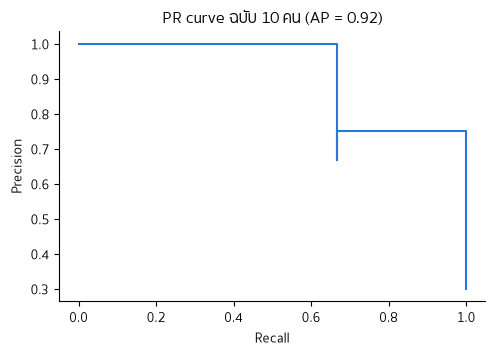

In [13]:
# ตัวอย่าง (เคสคู่ขนาน): เด็ก 10 คน ตัวจริง 3 — ลองเลื่อนเกณฑ์ดูไม้กระดก precision/recall
from sklearn.metrics import average_precision_score, precision_recall_curve

demo_risk = np.array([0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.15, 0.1])
demo_true = np.array([1,   1,   0,   1,   0,   0,   0,   0,   0,    0])

for thr in [0.65, 0.35]:
    flag = demo_risk >= thr
    tp = int((flag & (demo_true == 1)).sum())
    print(f"เกณฑ์ {thr}: ชี้ {flag.sum()} คน → ตัวจริง {tp} | "
          f"precision {tp / flag.sum():.2f} | recall {tp / 3:.2f}")

prec, rec, _ = precision_recall_curve(demo_true, demo_risk)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.step(rec, prec, where="post", color="#2a78d6")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"PR curve ฉบับ 10 คน (AP = {average_precision_score(demo_true, demo_risk):.2f})")
plt.show()

### [แบบฝึกหัด 5.3] PR curve + AP ของโมเดลจริง บนข้อสอบปี 2569

ใช้ `proba_ok` (canonical จาก checkpoint — เผื่อข้อ 5.2 ยังไม่ผ่าน) คู่กับ `y_test`

**คำสั่ง:**
1. `precision, recall, _ = precision_recall_curve(y_test, proba_ok)`
2. `ap = average_precision_score(y_test, proba_ok)`
3. วาดกราฟ: เส้น PR ของโมเดล + เส้นประแนวนอนที่ base rate (`y_test.mean()`)
   ใส่ label แกน x/y เป็นภาษาที่ทีมอ่านรู้เรื่อง + legend บอกค่า AP
4. ส่ง `ap` เข้า check

**ผลลัพธ์ที่คาด:** AP ≈ 0.22 เทียบ base rate 0.10 — เก่งกว่าเดามั่ว ~2.2 เท่า
curve จะสูงแถว precision 0.4–0.5 ช่วง recall ต่ำๆ แล้วค่อยๆ ไหลลงเข้าหา 0.10

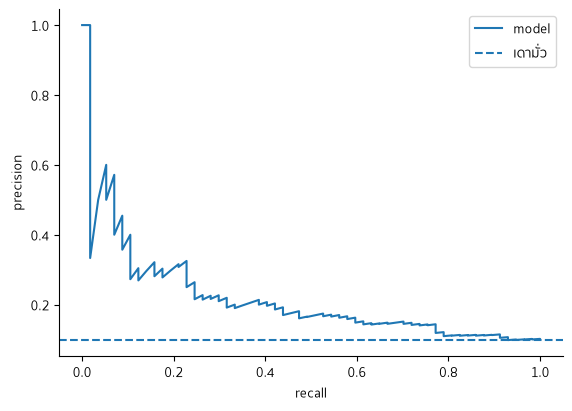

ผ่าน ✓  (ex_05_03) เยี่ยมมากครับ 🎉


True

In [14]:
# TODO: 1) precision_recall_curve  2) average_precision_score  3) วาดกราฟ
#   โครงกราฟ (ก๊อปจาก cell ตัวอย่างได้เลย):
#     fig, ax = plt.subplots(figsize=(6.5, 4.5))
#     ax.plot(recall, precision, label=...)      ← เส้นโมเดล
#     ax.axhline(y_test.mean(), ls="--", label=...)   ← เส้นเดามั่ว
#     ax.set_xlabel(...); ax.set_ylabel(...); ax.legend(); plt.show()
____ = None   # ← ลบบรรทัดนี้ แล้วเขียนโค้ดของคุณแทน
from sklearn.metrics import average_precision_score, precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, proba_ok)
ap = average_precision_score(y_test, proba_ok)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(recall, precision, label="model")     
ax.axhline(y_test.mean(), ls="--", label="เดามั่ว")  
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.legend(); plt.show()

checks.check("ex_05_03", ap)

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

ทั้งสองฟังก์ชันรับ (เฉลยจริง, คะแนน) ตามลำดับนี้เสมอ — ห้ามสลับ ·
โครงกราฟเหมือน cell ตัวอย่างเลย เปลี่ยนข้อมูลเป็นของจริง แล้วเพิ่มเส้นประ
แนวนอนที่ระดับ base rate ไว้เป็นเส้น "เดามั่ว" เทียบสายตา
พร้อมป้ายแกนสองแกนและ legend ที่บอกค่า AP

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `precision_recall_curve(เฉลยจริง, คะแนน)` — คืน 3 ค่า (precision, recall, thresholds)
- `average_precision_score(เฉลยจริง, คะแนน)`
- `ax.plot(...)` · `ax.axhline(..., ls="--")` · `ax.legend()`

</details>

In [15]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_05_03.py

**วิธีอ่าน PR curve (เก็บไว้อ่านทุกครั้งที่เจอ):**
- ทุกจุดบนเส้น = เกณฑ์หนึ่งค่า · **มุมขวาล่าง** = เกณฑ์หลวมสุด (ชี้หมดทุกคน:
  recall 1.0 แต่ precision = base rate 0.10) · **ไล่ไปทางซ้าย** = เข้มขึ้นเรื่อยๆ
- ของเรา: ยอมรับ recall ~0.16 (ชี้แคบๆ) จะได้ precision ~0.28–0.30 ·
  ถ้าอยากได้ recall ครึ่งหนึ่งของตัวจริงทั้งหมด ต้องยอม precision เหลือ ~0.17
- AP 0.22 ยังห่างจาก 1.0 มาก — ปกติครับสำหรับปัญหาพฤติกรรมมนุษย์ + โมเดลแรก
  สิ่งที่ต้องเช็คไม่ใช่ "ใกล้ 1 ไหม" แต่คือ **"ชนะ baseline ที่ใช้อยู่จริงหรือเปล่า"** (ข้อ 5.5)
- แถมมุมกลับ: ถ้าวันไหน AP พุ่งไป 0.9+ อย่าเพิ่งเลี้ยงฉลอง — สูดหายใจแล้วนึกถึง
  บทเรียน leakage จากบท 04 ก่อนเลย

In [16]:
# checkpoint: ค่า canonical ของ 5.3
ap_ok = average_precision_score(y_test, proba_ok)
print(f"ap_ok = {ap_ok:.3f} | base rate = {y_test.mean():.3f}")

ap_ok = 0.223 | base rate = 0.100


## [แนวคิด] 5.4 precision@k — ตัววัดที่ mentor เอาไปใช้ได้พรุ่งนี้เช้า

โลกจริงของทีมเรา: mentor หนึ่งคนโทรคุยกับน้อง + ผู้ปกครองได้จริงประมาณ
**30 สายต่อเดือน** (สายละ 15–20 นาที ไหนจะงานอื่นอีก) — คำถามธุรกิจจึงไม่ใช่
"เกณฑ์ 0.5 ชี้กี่คน" แต่คือ **"ถ้าโทรได้ 30 สาย ควรโทรหาใคร แล้วเจอตัวจริงกี่คน"**

นั่นคือ **precision@k**: เรียงทุกคนตามคะแนนเสี่ยง → หยิบ top-k → ดูสัดส่วนตัวจริงใน k คนนั้น
เราใช้ตัว canonical `churn_utils.precision_at_k(y_true, y_score, k)` ได้เลย

ไม้บรรทัดเทียบ: โทรสุ่ม 30 สาย จะเจอตัวจริงเฉลี่ย ~base rate = 10% ≈ **3 คน**
โมเดลที่มีประโยชน์ต้องพา mentor ไปเจอมากกว่านั้นชัดๆ

In [17]:
# ตัวอย่าง (เคสคู่ขนาน): ลิสต์ 10 คนเดิม — งบโทรแค่ 3 สาย ควรเจอกี่คน?
p3 = churn_utils.precision_at_k(demo_true, demo_risk, 3)
print(f"precision@3 = {p3:.3f} → โทร 3 คนแรกของลิสต์ เจอตัวจริง {round(p3 * 3)} คน (จากตัวจริงทั้งหมด 3)")

# แล้วหัวลิสต์ของโมเดลจริงหน้าตาเป็นยังไง? (5 อันดับแรกของปี 2569)
ranked = (test_df.assign(risk=proba_ok)
                 .sort_values("risk", ascending=False)
                 [["student_key", "month", "risk", "att_month_pct", "max_silent_weeks", "churned_next_month"]])
print("\nหัวลิสต์โทรของ mentor (คอลัมน์ท้ายสุด = เฉลยจริง — ตอนใช้งานจริงยังไม่มีให้ดูนะครับ):")
print(ranked.head(5).round(3).to_string(index=False))

precision@3 = 0.667 → โทร 3 คนแรกของลิสต์ เจอตัวจริง 2 คน (จากตัวจริงทั้งหมด 3)

หัวลิสต์โทรของ mentor (คอลัมน์ท้ายสุด = เฉลยจริง — ตอนใช้งานจริงยังไม่มีให้ดูนะครับ):
   student_key   month  risk  att_month_pct  max_silent_weeks  churned_next_month
uuid-2569-2088 2026-03 0.895         11.111                 3                 1.0
uuid-2569-2139 2026-07 0.872         35.714                 0                 0.0
uuid-2569-2029 2026-07 0.858         66.667                 0                 0.0
uuid-2569-2082 2026-07 0.856         50.000                 1                 1.0
uuid-2569-2052 2026-04 0.846         50.000                 0                 1.0


### [แบบฝึกหัด 5.4] precision@30 ของโมเดลเรา

**คำสั่ง:**
1. คำนวณ `p_at_30` ด้วย `churn_utils.precision_at_k` จาก `y_test`, `proba_ok`, k=30
2. print แปลผลเป็นภาษาคน: โทร 30 สาย เจอตัวจริงกี่คน เทียบกับโทรสุ่ม
3. ส่ง `p_at_30` เข้า check

**ผลลัพธ์ที่คาด:** 0.30 — ใน 30 สายแรกตามลิสต์โมเดล มีตัวจริง 9 คน

In [18]:
# TODO: precision@30 — บรรทัดเดียวถึง แล้วอย่าลืม print แปลผลให้ทีมอ่านรู้เรื่อง
____ = None   # ← ลบบรรทัดนี้ แล้วเขียนโค้ดของคุณแทน

p_at_30 = churn_utils.precision_at_k(y_test, proba_ok, k=30)
print(f"precision@30 = {p_at_30:.3f} → โทร 30 สายบนสุดของลิสต์ จะเจอน้องที่กำลังจะหายจริง ~{round(p_at_30 * 30)} คน "
      f"(ถ้าสุ่มโทร 30 สาย จะเจอแค่ ~{round(y_test.mean() * 30)} คน)")


checks.check("ex_05_04", p_at_30)

precision@30 = 0.300 → โทร 30 สายบนสุดของลิสต์ จะเจอน้องที่กำลังจะหายจริง ~9 คน (ถ้าสุ่มโทร 30 สาย จะเจอแค่ ~3 คน)
ผ่าน ✓  (ex_05_04) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

ฟังก์ชัน canonical ของทีมรับ (เฉลยจริง, คะแนน, k) — ลำดับเดียวกับตระกูล sklearn ·
จำนวนคนที่เจอ = สัดส่วนที่ได้คูณด้วยจำนวนสาย ส่วนไม้บรรทัดฝั่งสุ่มคือ
base rate ของข้อสอบคูณด้วยจำนวนสายเท่ากัน

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `churn_utils.precision_at_k(เฉลยจริง, คะแนน, 30)`
- แปลเป็นจำนวนคน: `round(... * 30)`

</details>

In [19]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_05_04.py

**ตีความเชิงธุรกิจ:** โทร 30 สายเท่ากันเป๊ะ —
- โทรสุ่ม: เจอตัวจริง ~3 คน · **โทรตามลิสต์โมเดล: 9 คน = 3 เท่าของสุ่ม**
- น้อง 1 คนที่รั้งไว้ได้ = subscription รายเดือนที่เดินต่อ + ผู้ปกครองที่ยังเชื่อใจระบบเรา
  ต่อให้คุยแล้วรั้งอยู่แค่ 2–3 คนจาก 9 ก็คุ้มค่าสาย 30 สายนั้นแล้ว
- ที่เหลืออีก 21 สายก็ไม่ใช่ "โทรฟรี" ซะทีเดียว — เด็กที่คะแนนเสี่ยงสูงแต่ยังไม่ churn
  คือกลุ่มเปราะบางที่ได้กำลังใจก่อนใครพอดี (นี่คือเหตุผลที่เราไม่ตัดสินโมเดลด้วย accuracy)

In [20]:
# checkpoint: ค่า canonical ของ 5.4
p30_ok = churn_utils.precision_at_k(y_test, proba_ok, 30)
print(f"p30_ok = {p30_ok:.3f} → เจอตัวจริง {round(p30_ok * 30)} คนใน 30 สาย")

p30_ok = 0.300 → เจอตัวจริง 9 คนใน 30 สาย


## [แนวคิด] 5.5 สังเวียน baseline — โมเดลต้องชนะใครถึงจะได้ไปต่อ

โมเดลใหม่ไม่ได้แข่งกับ "ความว่างเปล่า" — มันแข่งกับ**วิธีที่ทีมใช้อยู่แล้ว** คู่ชก 2 ราย:

1. **เดามั่ว (base rate)** — สอบผ่านขั้นต่ำ: AP ≈ 0.10, โทรสุ่ม 30 ก็เจอ ~10%
   แพ้อันนี้ = โยนโมเดลทิ้งได้เลย
2. **Tier heuristic** — ระบบสีเขียว/เหลือง/ส้ม/แดงที่ mentor ใช้จริงทุกสัปดาห์:
   ตัดจาก % เข้าเรียนรายสัปดาห์ ≥75 = เขียว / ≥50 = เหลือง / ≥25 = ส้ม / ต่ำกว่านั้น = แดง
   บวกกฎเสริม เงียบต่อเนื่อง ≥2 สัปดาห์ = แดงทันที (นิยามเดียวกับบท 03)
   (canonical: `churn_utils.tier_baseline_score` หยิบ tier สัปดาห์สุดท้ายของเดือน
   → คะแนน 0–3) — **คู่ชกตัวจริง**: ถ้าโมเดลไม่ชนะของฟรีที่มีอยู่แล้ว จะลงทุนเปลี่ยนทำไม?

จุดอ่อนของ tier ที่ควรสังเกต: คะแนนมีแค่ 4 ขั้น เด็กเป็นร้อยคนเลยเสมอกันเป็นกระจุก —
เรียงหัวลิสต์ 30 คนแบบละเอียดไม่ได้ ส่วนโมเดลให้คะแนนละเอียดถึงทศนิยม เรียงได้ทั้งแถว

In [21]:
# ตัวอย่าง (เคสคู่ขนาน): ลองวัด tier heuristic บนปี 2568 ก่อน (ข้อจริงคุณจะวัดบนปี 2569)
tier_train = churn_utils.tier_baseline_score(train_df, weekly)
print("การกระจายคะแนน tier ปี 68 (0=เขียว … 3=แดง):")
print(tier_train.value_counts().sort_index().to_string())
print(f"\nAP ของ tier บนปี 68 : {average_precision_score(y_train, tier_train):.3f}"
      f"  (base ปี 68 = {y_train.mean():.3f} — ชนะเดามั่วแบบหืดจับ)")

การกระจายคะแนน tier ปี 68 (0=เขียว … 3=แดง):
tier_score
0    510
1    170
2     56
3     27

AP ของ tier บนปี 68 : 0.096  (base ปี 68 = 0.079 — ชนะเดามั่วแบบหืดจับ)


### [แบบฝึกหัด 5.5] ตารางประลอง: เดามั่ว vs tier vs โมเดล

สร้างตารางสรุปแมตช์บนข้อสอบปี 2569 — ตารางนี้แหละคือสไลด์ที่เอาไปคุยกับทีมได้เลย

**คำสั่ง:**
1. `base` = base rate ของ `y_test` · `tier_score` = `churn_utils.tier_baseline_score(test_df, weekly)`
2. สร้าง DataFrame ชื่อ `baseline_table` 3 คอลัมน์: `baseline`, `ap`, `precision_at_30`
   และ 3 แถวชื่อเป๊ะๆ: `"base_rate"`, `"tier"`, `"model"`
3. เติมค่า: แถว base_rate ใช้ `base` ทั้งสองช่อง (เดามั่ว: ค่าคาดหวัง = base rate) ·
   แถว tier กับ model คำนวณ AP (`average_precision_score`) และ precision@30
   (`churn_utils.precision_at_k`) จาก `tier_score` และ `proba_ok` ตามลำดับ
4. print ตาราง (ปัด 3 ตำแหน่ง) แล้วส่ง `baseline_table` เข้า check

**ผลลัพธ์ที่คาด:** base_rate 0.100/0.100 · tier ≈ 0.157/0.233 · model ≈ 0.223/0.300

In [22]:
# TODO: ประกอบตารางประลอง 3 แถว × 3 คอลัมน์ ตามคำสั่ง
____ = None   # ← ลบบรรทัดนี้ แล้วเขียนโค้ดของคุณแทน

base = y_test.mean()                                          # เดามั่ว: ความแม่น = base rate (0.102)
tier_score = churn_utils.tier_baseline_score(test_df, weekly)
ap_tier  = average_precision_score(y_test, tier_score)
ap_model = average_precision_score(y_test, proba_ok)
p30_tier  = churn_utils.precision_at_k(y_test, tier_score, 30)
p30_model = churn_utils.precision_at_k(y_test, proba_ok, 30)

baseline_table = pd.DataFrame({
    "baseline":        ["base_rate", "tier",   "model"],      # คอลัมน์ชื่อแถว (ต้องสะกดเป๊ะ check ดูชื่อนี้)
    "ap":              [base,        ap_tier,  ap_model],
    "precision_at_30": [base,        p30_tier, p30_model],
})
print(baseline_table.round(3))
checks.check("ex_05_05", baseline_table)

  # ไฟ 4 สี → คะแนน 0-3 (ท่าเดิมจาก cell ตัวอย่าง แค่เปลี่ยน train→test)
# proba_ok = คะแนนโมเดล — มีอยู่แล้วจากข้อ 5.2


    baseline     ap  precision_at_30
0  base_rate  0.100            0.100
1       tier  0.157            0.233
2      model  0.223            0.300
ผ่าน ✓  (ex_05_05) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

สร้างเป็น dict สามคีย์ (คีย์ละหนึ่งคอลัมน์ ค่าเป็นลิสต์ยาวสาม) แล้วห่อเป็น DataFrame
เรียงแถวตามลำดับ base_rate → tier → model · แถว tier กับ model ใช้ฟังก์ชันวัด
ตัวเดียวกันเป๊ะ ต่างกันแค่คะแนนที่ป้อน (คะแนนจาก tier vs คะแนนจากโมเดล)

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `churn_utils.tier_baseline_score(..., ...)` — ป้อนตารางแถวปี 2569 คู่กับตาราง weekly metrics
- `average_precision_score(เฉลยจริง, คะแนน)` และ `churn_utils.precision_at_k(เฉลยจริง, คะแนน, 30)`
  — เรียกซ้ำได้ทั้งฝั่ง tier และฝั่งโมเดล
- `pd.DataFrame({"ชื่อคอลัมน์": [ค่าทั้งสามแถว], ...})`

</details>

In [23]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_05_05.py

**คำตัดสิน: โมเดลชนะ — แต่ชนะแบบมีการบ้านต่อ**

| ผู้ท้าชิง | AP | โทร 30 เจอ |
|---|---|---|
| เดามั่ว | 0.100 | ~3 คน |
| tier ของ mentor | ~0.157 | ~7 คน |
| **โมเดลแรกของเรา** | **~0.223** | **~9 คน** |

- ชนะ tier ทั้งสองกระดาน: AP ดีกว่า ~40% และเก็บตัวจริงเพิ่ม +2 คนต่อรอบโทร 30 สาย
- มองโลกตรงๆ: +2 คน/เดือน ฟังดูไม่หวือหวา — แต่สะสมทั้งซีซัน + ความสามารถ
  "เรียงละเอียดทั้งแถว + บอกเหตุผลรายคน (บท 07)" คือของที่ tier ให้ไม่ได้เลย
- และนี่คือโมเดล**แรก** ยังไม่จูนอะไรสักอย่าง — ยังมีของให้รีดอีกในบทหน้า

## สรุปสิ่งที่ได้จากบทนี้

- **ท่อครบวงจร**: `ColumnTransformer` (imputer median + scaler / one-hot ignore-unknown)
  ต่อเข้า `Pipeline` กับ `LogisticRegression(class_weight="balanced")` — fit ทีเดียว
  กัน leakage ให้ทั้งท่อ และกฎเหล็กใหม่: **test โดนได้แค่ transform/predict ห้ามโดน fit**
- **Accuracy โกหก** เมื่อ churn ~9% (หมอดูขี้เกียจได้ 91% ฟรี) → เราวัดด้วย
  precision / recall / PR curve / AP และตัวเด็ดสุดคือ **precision@30** ที่แปลตรงเป็น
  "โทร 30 สาย เจอตัวจริง 9 คน = 3 เท่าของสุ่ม"
- **โมเดลแรกชนะ baseline จริง**: AP 0.223 vs tier 0.157 vs เดามั่ว 0.100 —
  ผ่านด่าน "คุ้มกว่าของที่ใช้อยู่" มาได้ มีสิทธิ์ไปต่อ

**บทต่อไป (06):** ตอนนี้เราวัดจากข้อสอบชุดเดียว (ปี 69 ทั้งปี) — มันนิ่งพอไหม?
เดือนไหนโมเดลเก่ง/ห่วย? โมเดลตัวอื่นจะแซง LogReg ไหม? บท 06 จะวัดผลแบบเข้มข้น
ตามเส้นเวลา จูนให้สุด แล้วเลือกแชมป์ตัวจริงเซฟไว้ใช้งาน — ก่อนส่งไม้ต่อให้บท 07
เปิดฝาโมเดลอธิบายรายคน และบท 08 ต่อท่อเข้าระบบจริงให้ mentor ใช้ทุกเดือนครับ 💪